In [2]:
import intake
import cartopy.crs as ccrs
import cmocean
import healpy as hp
import easygems.healpix as egh
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from pathlib import Path # Object oriented libary to deal with paths
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
import sys
sys.path.append('/work/mh0731/m300876/package')
import icons

In [3]:
### preprocess to modify data set
def preprocess(ds):
    """
    Adapts precipitation to the needs of this notebook.
    """
    ds = ds.assign(pr=(ds.pr * 86400).assign_attrs(units="mm d-1"))
    return ds

In [4]:
### Location mask
def tropics(ds):
    return np.abs(ds.lat) <= 30.1

def land(ds):
    return ds.ocean_fraction_surface == 0

def ocean(ds):
    return ds.ocean_fraction_surface == 1

In [5]:
def land_sea_mask(dset):
    ##This function calculate the land_sea mask according to the resolution of the data##
    ###negative values is ocean, positive values is land
    filemask = '/work/mh0731/from_Mistral/mh0731/m300876/land_sea_mask/GPM_IMERG_LandSeaMask.2.nc4'
    dsetmask = xr.open_dataset(filemask).sortby('lat', ascending=False)
    lon_new = xr.where(dsetmask.lon>0,dsetmask.lon,dsetmask.lon+360)
    dsetmask = dsetmask.assign_coords({'lon':lon_new}).sortby('lon',ascending=True)
    lsmask01 = dsetmask.landseamask.where(
        dsetmask.landseamask<100).interp(lon=dset.lon.values,lat=dset.lat.values,method='linear') *0 +2
    lsmask01 = lsmask01.where(lsmask01==2,-2)
    return lsmask01.compute()

In [10]:
def time_mean_imerg(file,lon,lat,environ):
    ##Funtion to calculate the climatology monthly mean of precipitation from IMERG
    ###the environ option mask the values over land or ocean:
        ## if environ = 'trop' -> no mask is used
        ## if environ = 'ocean' -> return only values over ocean
        ## if environ = 'land' -> return only values over land
    data = xr.open_mfdataset(
        file,engine='zarr',chunks='auto')['pr']
    
    pr = data.groupby('time.month').mean()

    
    if environ is 'trop':
        ptrop=pr.sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
    else:
        lsmask01 = land_sea_mask(data)
        if environ is 'ocean':
            ptrop=pr.where(lsmask01<0).sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
        elif environ is 'land':
            ptrop=pr.where(lsmask01>0).sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
        else:
            return print('Something is wrong')
    
    return ptrop.compute()

In [7]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
exp_name = "ngc4008"
experiment = cat.ICON[exp_name]
time_slice = slice("2021-02-01", "2021-02-28")
ds4008 = (
    experiment(zoom=9, time="P1D", chunks="auto")
    .to_dask()
    .pipe(preprocess)
    .sel(time=time_slice)
)

In [8]:
%%time
### ICON
current_location = "online"
cat = intake.open_catalog(
    "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")[current_location]
exp_name = "icon_d3hp003"
experiment = cat[exp_name]
time_slice = slice("2020-02-01", "2021-01-31")
ds_icon = (
    experiment(zoom=9, time="P1D", chunks="auto")
    .to_dask()
    .pipe(egh.attach_coords)
    .pipe(preprocess)
    .sel(time=time_slice)
)

CPU times: user 1.08 s, sys: 44.4 ms, total: 1.12 s
Wall time: 1.26 s


In [9]:
pr_icon = ds_icon.pr.where(tropics(ds_icon) & ocean(ds4008)).drop(('lat','lon')).groupby("time.month").mean().compute()

**IMERG**

In [11]:
file_imerg = '/scratch/m/m301226/sourceDatasets/REORGANIZED_IMERG_Tot_Precip_NetCDF.zarr'
pr_imerg = time_mean_imerg(file_imerg,[0,360],[30,-30],'ocean')

In [12]:
lon_180 = xr.where(pr_imerg.lon<180,pr_imerg.lon,pr_imerg.lon-360)
pr_imerg2 = pr_imerg.assign_coords({'lon':lon_180}).sortby(['lon','lat'])

### Interpolate healpix into lat-lon

In [13]:
def get_nn_lon_lat_index(nside, lons, lats):
    lons2, lats2 = np.meshgrid(lons, lats)
    return xr.DataArray(
        hp.ang2pix(nside, lons2, lats2, nest=True, lonlat=True),
        coords=[("lat", lats), ("lon", lons)],
    )

In [14]:
idx = get_nn_lon_lat_index(
    2**9, np.linspace(-180, 180, 3600), np.linspace(-30, 30, 601)
)

In [15]:
pr_lon_lat_ocean = pr_icon.isel(cell=idx)

### Function to calculate object detection

In [16]:
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib import pyplot as plt # Standard Plotting library
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [17]:
def calc_area(data,dx,dy):
    ##Calculate the area of each grid cell in the data
    earthr = 6.371e6
    loncmorph,latcmorph = np.meshgrid(data.lon.values,data.lat.values)
    area = xr.DataArray(data = (dx/180*np.pi)*earthr*np.cos(latcmorph/180*np.pi)*(dy/180*np.pi)*earthr,
                            dims=["lat","lon"],
                            coords=dict(
                            lat=(["lat"],data.lat.values),
                            lon=(["lon"],data.lon.values),))
    return area

In [18]:
def calc_objects(data,threshold,structure):
    ## This function calculates the objects of precipitation according to a threshold and a strcuture
    labels,num = measurements.label(data.where(data>threshold,0),structure=structure)
    ###sorting labels according to index
    labelsu = np.unique(labels)
    labels_n = np.searchsorted(labelsu,labels)
    indices_n = np.arange(np.max(labels_n)+1)
    return labels_n,indices_n

In [19]:
def cal_statistic(data,area_grid,labels_n,indices_n,threshold):
    ## This function calculates the statistics of the objects as: 
        ##area 
        ##mean precipitation
        ##centroid (longitude and latitude)
    sum_area=ndimage.sum(area_grid,labels_n,indices_n)
    meanp = ndimage.mean((data).where(data>threshold,0),labels_n,indices_n)
    meanp_area = (ndimage.mean(data,labels_n,indices_n)/(ndimage.sum(area_grid,labels_n,indices_n)))
    centr_lat = [data.lat.values[int(ndimage.center_of_mass((data),labels_n,indices_n)[j][0])] for j in range(
        len(indices_n))]
    centr_lon = [data.lon.values[int(ndimage.center_of_mass((data),labels_n,indices_n)[j][1])] for j in range(
        len(indices_n))]
    
    stats  = np.zeros((5,len(indices_n)))
    stats[0,:] = sum_area
    stats[1,:] = meanp
    stats[2,:] = meanp_area
    stats[3,:] = centr_lat
    stats[4,:] = centr_lon
    
    return meanp, sum_area, stats

In [20]:
def cal_max_object(data,stats,labels_n,indices_n,sum_area,meanp,threshold,area_min):
    ##This function caluclates the object with the maximum area 
    sel_ind = indices_n[(meanp>threshold) & (sum_area/1000000>(area_min))]
    nstats = [stats[:,indices_n==sel_ind[i]] for i in range(len(sel_ind))]
    nlabel = [np.where(labels_n==sel_ind[i], data, np.nan) for i in range(len(sel_ind))]
    
    if not sel_ind.any():
        nstats = [np.zeros((5,1))*np.nan]
        return nstats,nlabel
    elif len(sel_ind) == 1:
        return nstats,nlabel
    else:
        area = [nstats[i][0] for i in range(len(sel_ind))]
        max_tuple = max(area, key=lambda x:x[0])
        max_ind = area.index(max_tuple)

        return [nstats[max_ind]], [nlabel[max_ind]]

In [21]:
def object_id(data,dx,dy,structure,threshold,area_min):
    ####create area
    area_grid = calc_area(data,dx,dy) 
    ###calculating objects
    labels_n,indices_n = calc_objects(data,threshold,structure)
    
    ###calculate stats
    meanp, sum_area, stats = cal_statistic(data,area_grid,labels_n,indices_n,threshold)

    ###selecting only the according to the classification 
    return cal_max_object(data,stats,labels_n,indices_n,sum_area,meanp,threshold,area_min)

**Calculate the percentile 80 over land**

In [22]:
pr_ocean_q80 = pr_lon_lat_ocean.quantile(0.8,dim=('lon','lat'))
pr_imerg_ocean_q80 = pr_imerg2.quantile(0.8,dim=('lon','lat'))

**Converting nan values to zero to use in the object detection**

In [23]:
pr2_ocean = pr_lon_lat_ocean.where(pr_lon_lat_ocean>=0,0)
pr2_imerg_ocean = pr_imerg2.where(pr_imerg2>=0,0)

**Choose the structure to use in the object detection**

In [24]:
s = ndimage.generate_binary_structure(2,2)

### Tropical Rainbelt for tropical ocean

**Atlantic**

In [25]:
##ICON-S
atl_stats =  [object_id(pr2_ocean[i,:,:].sel(lat=slice(-10,20),lon=slice(-60,10)),0.1,0.1,s,\
                                     pr_ocean_q80[i].values,[500*500]) for i in range(pr_ocean_q80.size)]

In [26]:
atl_area = [atl_stats[i][0][0][0] for i in range(pr_ocean_q80.size)]
atl_loni = [atl_stats[i][0][0][-1] for i in range(pr_ocean_q80.size)]
atl_lati = [atl_stats[i][0][0][-2] for i in range(pr_ocean_q80.size)]

In [27]:
##IMERG
atl_imerg_stats =  [object_id(pr2_imerg_ocean[i,:,:].sel(lat=slice(-10,20),lon=slice(-60,10)),0.1,0.1,\
                              s,pr_imerg_ocean_q80[i].values,[500*500]) for i in range(pr_imerg_ocean_q80.size)]

atl_area_imerg = [atl_imerg_stats[i][0][0][0] for i in range(pr_imerg_ocean_q80.size)]
atl_loni_imerg = [atl_imerg_stats[i][0][0][-1] for i in range(pr_imerg_ocean_q80.size)]
atl_lati_imerg = [atl_imerg_stats[i][0][0][-2] for i in range(pr_imerg_ocean_q80.size)]

**E. Pacific**

In [28]:
epac_stats =  [object_id(pr2_ocean[i,:,:].sel(lat=slice(0,20),lon=slice(-150,-80)),0.1,0.1,s,\
                                     pr_ocean_q80[i].values,[500*500]) for i in range(pr_ocean_q80.size)]

## Area, longitud, latitud
epac_area = [epac_stats[i][0][0][0] for i in range(pr_ocean_q80.size)]
epac_loni = [epac_stats[i][0][0][-1] for i in range(pr_ocean_q80.size)]
epac_lati = [epac_stats[i][0][0][-2] for i in range(pr_ocean_q80.size)]

In [29]:
epac_imerg_stats =  [object_id(pr2_imerg_ocean[i,:,:].sel(lat=slice(0,20),lon=slice(-150,-80)),0.1,0.1,s,\
                                     pr_imerg_ocean_q80[i].values,[500*500]) for i in range(pr_imerg_ocean_q80.size)]

epac_area_imerg = [epac_imerg_stats[i][0][0][0] for i in range(pr_imerg_ocean_q80.size)]
epac_loni_imerg = [epac_imerg_stats[i][0][0][-1] for i in range(pr_imerg_ocean_q80.size)]
epac_lati_imerg = [epac_imerg_stats[i][0][0][-2] for i in range(pr_imerg_ocean_q80.size)]

**Indian ocean**

In [30]:
ind_stats =  [object_id(pr2_ocean[i,:,:].sel(lat=slice(-30,30),lon=slice(50,105)),0.1,0.1,s,\
                                     pr_ocean_q80[i].values,[500*500]) for i in range(pr_ocean_q80.size)]

## Area, longitud, latitud
ind_area = [ind_stats[i][0][0][0] for i in range(pr_ocean_q80.size)]
ind_loni = [ind_stats[i][0][0][-1] for i in range(pr_ocean_q80.size)]
ind_lati = [ind_stats[i][0][0][-2] for i in range(pr_ocean_q80.size)]

In [31]:
ind_imerg_stats =  [object_id(pr2_imerg_ocean[i,:,:].sel(lat=slice(-30,30),lon=slice(50,105)),0.1,0.1,s,\
                              pr_imerg_ocean_q80[i].values,[500*500]) for i in range(pr_imerg_ocean_q80.size)]

ind_area_imerg = [ind_imerg_stats[i][0][0][0] for i in range(pr_imerg_ocean_q80.size)]
ind_loni_imerg = [ind_imerg_stats[i][0][0][-1] for i in range(pr_imerg_ocean_q80.size)]
ind_lati_imerg = [ind_imerg_stats[i][0][0][-2] for i in range(pr_imerg_ocean_q80.size)]

**Central western Pacific**

In [32]:
pr2_ocean2 = pr2_ocean.assign_coords(lon=("lon",np.where(pr2_ocean.lon.values>0,pr2_ocean.lon.values,\
                                                         pr2_ocean.lon.values+360))).sortby("lon")

pr2_imerg_ocean2 = pr2_imerg_ocean.assign_coords(lon=("lon",np.where(pr2_imerg_ocean.lon.values>0,\
                                pr2_imerg_ocean.lon.values,pr2_imerg_ocean.lon.values+360))).sortby("lon")


In [33]:
cpac2_stats =  [object_id(pr2_ocean2[i,:,:].sel(lat=slice(0,20),lon=slice(160,210)),0.1,0.1,s,\
                                     pr_ocean_q80[i].values,[500*500]) for i in range(pr_ocean_q80.size)]

cpac_area = [cpac2_stats[i][0][0][0] for i in range(pr_ocean_q80.size)]
cpac_loni = [cpac2_stats[i][0][0][-1] for i in range(pr_ocean_q80.size)]
cpac_lati = [cpac2_stats[i][0][0][-2] for i in range(pr_ocean_q80.size)]

In [34]:
cpac2_imerg_stats =  [object_id(pr2_imerg_ocean2[i,:,:].sel(lat=slice(0,20),lon=slice(160,210)),0.1,0.1,s,\
                                pr_imerg_ocean_q80[i].values,[500*500]) for i in range(pr_imerg_ocean_q80.size)]

cpac_area_imerg = [cpac2_imerg_stats[i][0][0][0] for i in range(pr_imerg_ocean_q80.size)]
cpac_loni_imerg = [cpac2_imerg_stats[i][0][0][-1] for i in range(pr_imerg_ocean_q80.size)]
cpac_lati_imerg = [cpac2_imerg_stats[i][0][0][-2] for i in range(pr_imerg_ocean_q80.size)]

**Southern Pacific**

In [35]:
spac2_stats =  [object_id(pr2_ocean2[i,:,:].sel(lat=slice(-30,0),lon=slice(160,240)),0.1,0.1,s,\
                                     pr_ocean_q80[i].values,[500*500]) for i in range(pr_ocean_q80.size)]

spac_area = [spac2_stats[i][0][0][0] for i in range(pr_ocean_q80.size)]
spac_loni = [spac2_stats[i][0][0][-1] for i in range(pr_ocean_q80.size)]
spac_lati = [spac2_stats[i][0][0][-2] for i in range(pr_ocean_q80.size)]

In [36]:
spac2_imerg_stats =  [object_id(pr2_imerg_ocean2[i,:,:].sel(lat=slice(-30,0),lon=slice(160,240)),0.1,0.1,s,\
                                pr_imerg_ocean_q80[i].values,[500*500]) for i in range(pr_imerg_ocean_q80.size)]

spac_area_imerg = [spac2_imerg_stats[i][0][0][0] for i in range(pr_imerg_ocean_q80.size)]
spac_loni_imerg = [spac2_imerg_stats[i][0][0][-1] for i in range(pr_imerg_ocean_q80.size)]
spac_lati_imerg = [spac2_imerg_stats[i][0][0][-2] for i in range(pr_imerg_ocean_q80.size)]

**Concatenate arrays**

In [37]:
scal_epac = np.concatenate(epac_area)
scal_cpac = np.concatenate(cpac_area)
scal_spac = np.concatenate(spac_area)
scal_atl = np.concatenate(atl_area)
scal_ind = np.concatenate(ind_area)

In [38]:
scal_epac_imerg = np.concatenate(epac_area_imerg)
scal_cpac_imerg = np.concatenate(cpac_area_imerg)
scal_spac_imerg = np.concatenate(spac_area_imerg)
scal_atl_imerg = np.concatenate(atl_area_imerg)
scal_ind_imerg = np.concatenate(ind_area_imerg)

**Plotting the movement of the tropical rainbelt over the ocean**

In [39]:
from cartopy import crs as ccrs # Cartography library
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cfeature
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib import pyplot as plt # Standard Plotting library
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib as mpl

In [40]:
colors = ['darkblue','darkblue','darkcyan','darkcyan','green','green','orange','orange','red','red','brown','brown']
colors_name = ['darkblue','darkcyan','green','orange','red','brown']
cmaps = (mpl.colors.ListedColormap(colors_name))
bounds = [1, 2, 3, 4, 5, 6, 7]
norms = mpl.colors.BoundaryNorm(bounds, cmaps.N)

[Text(1.5, 0, 'Jan-Feb'),
 Text(2.5, 0, 'Mar-Apr'),
 Text(3.5, 0, 'May-Jun'),
 Text(4.5, 0, 'Jul-Aug'),
 Text(5.5, 0, 'Sep-Oct'),
 Text(6.5, 0, 'Nov-Dec')]

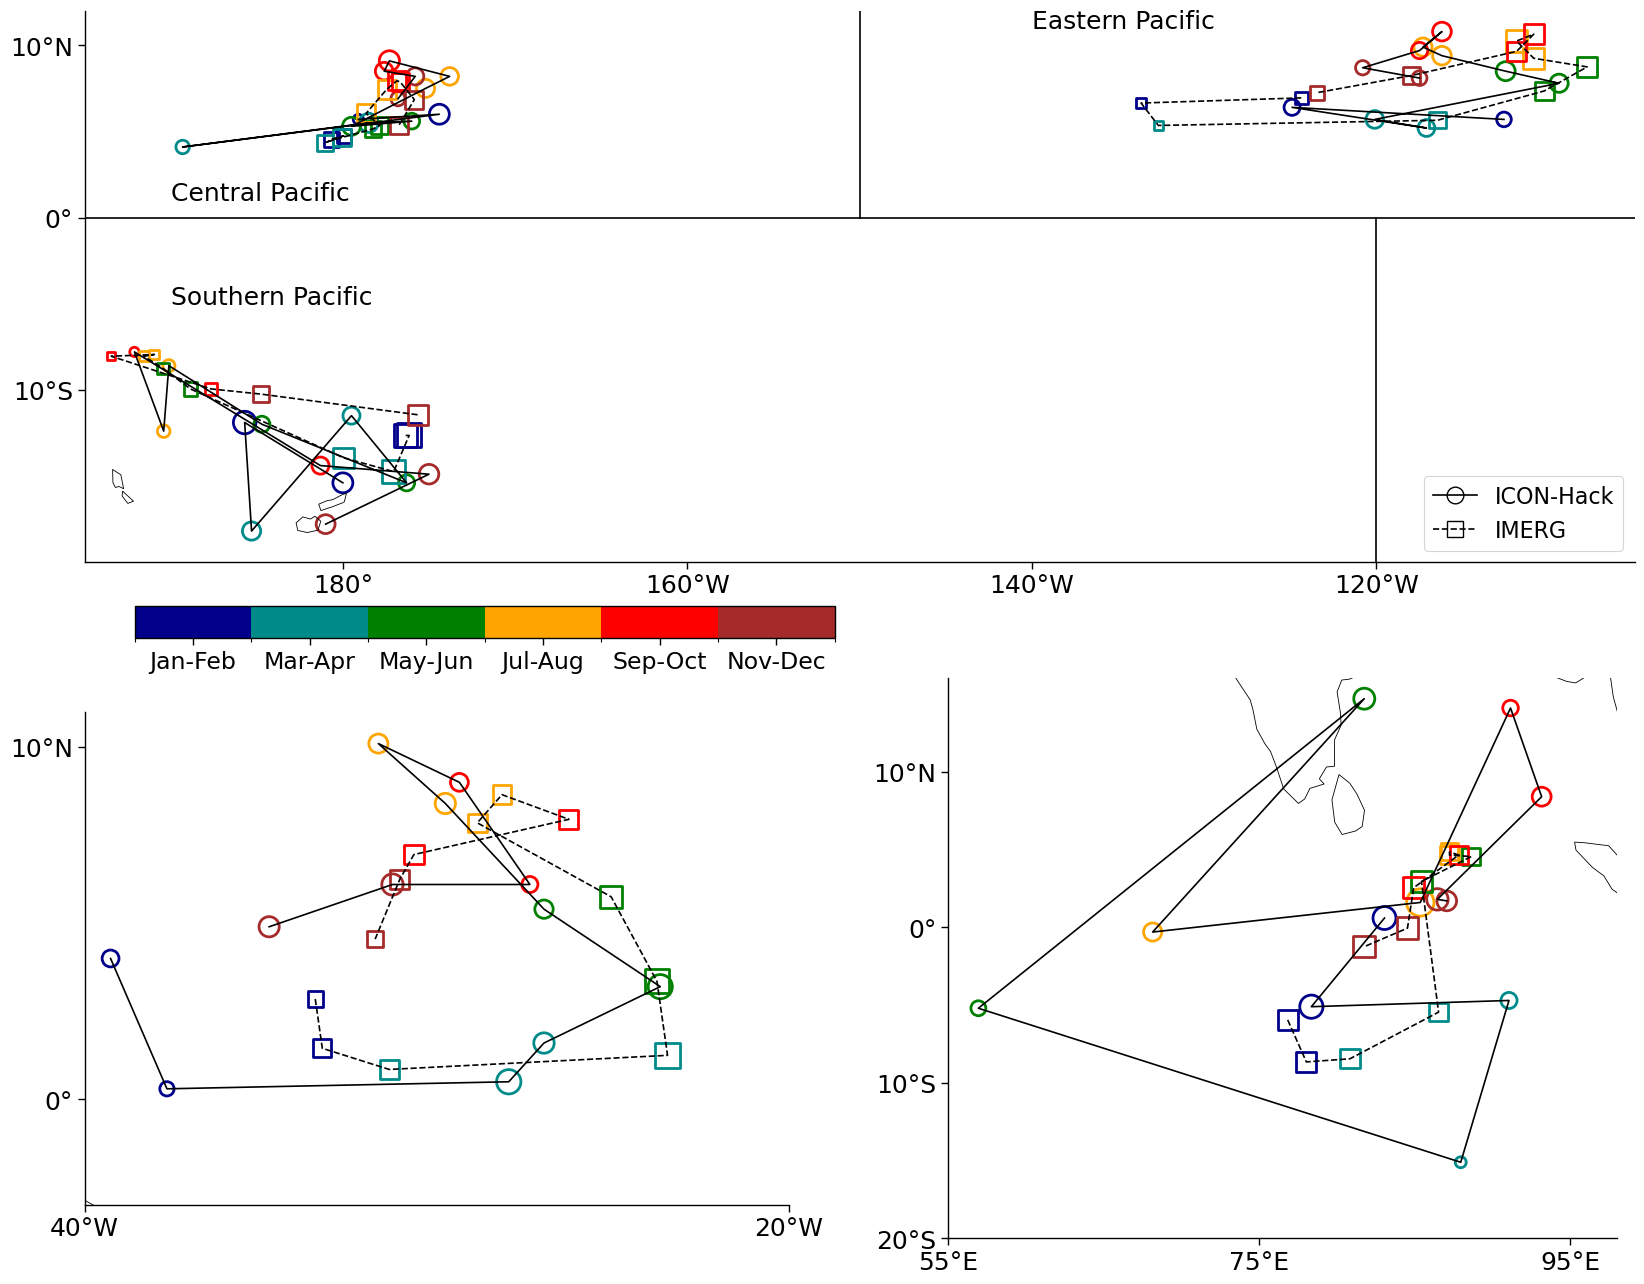

In [115]:
fig = plt.figure(figsize=(20, 16))
ax1=fig.add_axes([0.15,0.485,0.35,0.02])
ax0 = fig.add_subplot(211,projection=ccrs.PlateCarree(central_longitude=180))

###E.Pacific
cs0 = ax0.scatter(epac_loni,epac_lati,s=scal_epac/scal_epac.mean()*150,facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax0.plot(epac_loni,epac_lati,'-k',transform=ccrs.PlateCarree())
cs0_1 = ax0.scatter(epac_loni_imerg,epac_lati_imerg,s=scal_epac_imerg/scal_epac_imerg.mean()*150,marker='s',facecolors='none',edgecolors=colors,linewidth=2,transform=ccrs.PlateCarree())
ax0.plot(epac_loni_imerg,epac_lati_imerg,'-k',linestyle='--',transform=ccrs.PlateCarree())

ax0.scatter(cpac_loni,cpac_lati,s=scal_cpac/scal_cpac.mean()*150,facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax0.plot(cpac_loni,cpac_lati,'-k',transform=ccrs.PlateCarree())
ax0.scatter(cpac_loni_imerg,cpac_lati_imerg,s=scal_cpac_imerg/scal_cpac_imerg.mean()*150,marker='s',facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax0.plot(cpac_loni_imerg,cpac_lati_imerg,'-k',linestyle='--',transform=ccrs.PlateCarree())

cs1 = ax0.scatter(spac_loni,spac_lati,s=scal_spac/scal_spac.mean()*150,facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax0.plot(spac_loni,spac_lati,'-k',transform=ccrs.PlateCarree())
cs1_1 = ax0.scatter(spac_loni_imerg,spac_lati_imerg,s=scal_spac_imerg/scal_spac_imerg.mean()*150,marker='s',facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax0.plot(spac_loni_imerg,spac_lati_imerg,'-k',linestyle='--', transform=ccrs.PlateCarree())
ax0.set_extent([165,255, -20, 12], crs=ccrs.PlateCarree())
ax0.coastlines(resolution='110m',linewidth=0.6)
ax0.set_yticks(np.arange(-10,11,10),crs=ccrs.PlateCarree());lat_formatter = LatitudeFormatter();ax0.yaxis.set_major_formatter(lat_formatter)
ax0.set_xticks(np.arange(180,250,20),crs=ccrs.PlateCarree());lon_formatter = LongitudeFormatter();ax0.xaxis.set_major_formatter(lon_formatter)
ax0.tick_params(labelsize=18)

ax0.spines['geo'].set_visible(False)
ax0.spines['left'].set_visible(True)  
ax0.spines['bottom'].set_visible(True)  

###only for legend
ax0.plot(epac_loni,epac_lati,'-ok',markerfacecolor='none',markersize=12,label='ICON-Hack')
ax0.plot(epac_loni_imerg,epac_lati_imerg,'-sk',markerfacecolor='none',linestyle='--',markersize=12,label='IMERG')
leg0 = plt.legend(fontsize=16,loc=4)

ax0.plot([165, 255],[0, 0],'-k',transform=ccrs.PlateCarree())
ax0.plot([210, 210],[0, 20],'-k',transform=ccrs.PlateCarree())
ax0.plot([240, 240],[-20, 0],'-k',transform=ccrs.PlateCarree())


plt.text(40,11,'Eastern Pacific',fontsize=18)
plt.text(-10,1,'Central Pacific',fontsize=18)
plt.text(-10,-5,'Southern Pacific',fontsize=18)

ax = fig.add_subplot(223,projection=ccrs.PlateCarree(central_longitude=0))
cs2 = ax.scatter(atl_loni,atl_lati,s=scal_atl/scal_atl.mean()*200,facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax.plot(atl_loni,atl_lati,'-k',transform=ccrs.PlateCarree())
cs2_1 = ax.scatter(atl_loni_imerg,atl_lati_imerg,s=scal_atl_imerg/scal_atl_imerg.mean()*200 ,marker='s',facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax.plot(atl_loni_imerg,atl_lati_imerg,'-k',linestyle='--',transform=ccrs.PlateCarree()) 
ax.coastlines(resolution='110m',linewidth=0.6)
ax.spines['geo'].set_visible(False)
ax.spines['left'].set_visible(True)  
ax.spines['bottom'].set_visible(True)  
ax.set_extent([-40,-20, -3, 11], crs=ccrs.PlateCarree())
ax.set_yticks([0,10],crs=ccrs.PlateCarree());lat_formatter = LatitudeFormatter();ax.yaxis.set_major_formatter(lat_formatter)
ax.set_xticks(np.arange(-40,-9,20),crs=ccrs.PlateCarree());lon_formatter = LongitudeFormatter();ax.xaxis.set_major_formatter(lon_formatter)
ax.tick_params(labelsize=18)


ax = fig.add_subplot(224,projection=ccrs.PlateCarree(central_longitude=0))
ax.scatter(ind_loni,ind_lati,s=scal_ind/scal_ind.mean()*200,facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax.plot(ind_loni,ind_lati,'-k',transform=ccrs.PlateCarree())
ax.scatter(ind_loni_imerg,ind_lati_imerg,s=scal_ind_imerg/scal_ind_imerg.mean()*200,marker='s',facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax.plot(ind_loni_imerg,ind_lati_imerg,'-k',linestyle='--',transform=ccrs.PlateCarree()) 
ax.coastlines(resolution='110m',linewidth=0.6)
ax.set_extent([60,98, -20, 16], crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-20,16,10),crs=ccrs.PlateCarree());lat_formatter = LatitudeFormatter();ax.yaxis.set_major_formatter(lat_formatter)
ax.set_xticks(np.arange(55,98,20),crs=ccrs.PlateCarree());lon_formatter = LongitudeFormatter();ax.xaxis.set_major_formatter(lon_formatter)
ax.tick_params(labelsize=18)
ax.spines['geo'].set_visible(False)
ax.spines['left'].set_visible(True)  
ax.spines['bottom'].set_visible(True)  


cb1 = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmaps, norm=norms),
    cax=ax1,
    boundaries= bounds,  # Adding values for extensions.
    extend='neither',
    ticks=[1.5, 2.5, 3.5, 4.5, 5.5 , 6.5],
    spacing='proportional',
    orientation='horizontal',
)

cb1.ax.set_xticklabels(['Jan-Feb','Mar-Apr','May-Jun','Jul-Aug','Sep-Oct','Nov-Dec'],fontsize=17)

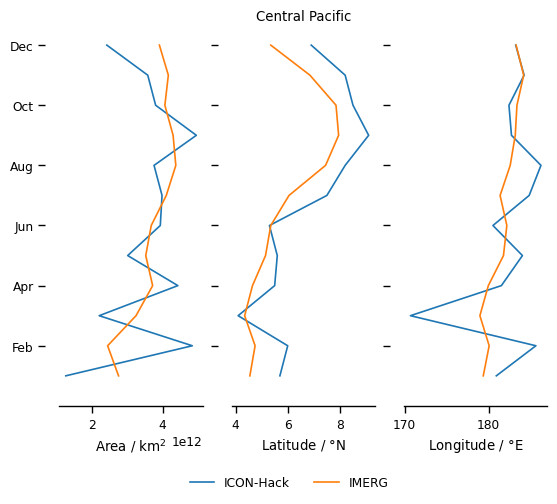

In [109]:
sns.set_context("paper") 
fig = plt.figure(figsize=(16/2.54, 12/2.54))
ax1 = fig.add_subplot(131)
ax1.plot(scal_cpac,pr_imerg.month)
ax1.plot(scal_cpac_imerg,pr_imerg.month)
sns.despine(offset=10,ax=ax1)
ax1.set_xlabel(r'Area / km$^\mathrm{2}$')
ax1.spines['left'].set_visible(False)
ax1.set_yticks([2,4,6,8,10,12])
ax1.set_yticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])

ax2 = fig.add_subplot(132)
ax2.plot(cpac_lati,pr_imerg.month)
ax2.plot(cpac_lati_imerg,pr_imerg.month)
sns.despine(offset=10,ax=ax2)
ax2.set_xlabel(r'Latitude / $\degree$N')
ax2.spines['left'].set_visible(False)
ax2.set_yticklabels({})
ax2.set_title('Central Pacific')

ax3 = fig.add_subplot(133)
ax3.plot(cpac_loni,pr_imerg.month,label='ICON-Hack')
ax3.plot(cpac_loni_imerg,pr_imerg.month,label='IMERG')

ax3.set_xlabel(r'Longitude / $\degree$E')
sns.despine(offset=10,ax=ax3)
ax3.spines['left'].set_visible(False)
ax3.set_yticklabels({});

ax3.legend(loc='upper center', bbox_to_anchor=(-0.8, -0.2),
          ncol=2,frameon=False)

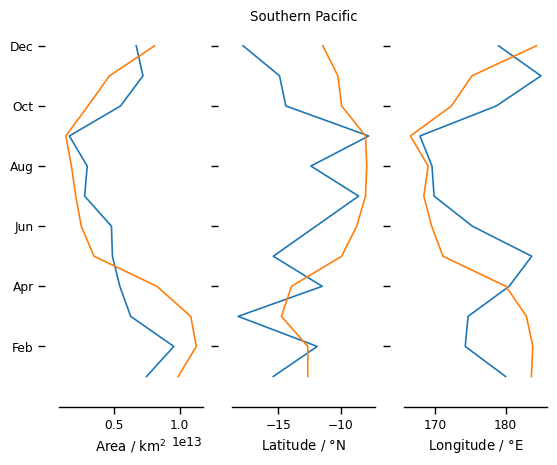

In [ ]:
sns.set_context("paper") 
fig = plt.figure(figsize=(16/2.54, 12/2.54))
ax1 = fig.add_subplot(131)
ax1.plot(scal_spac,pr_imerg.month)
ax1.plot(scal_spac_imerg,pr_imerg.month)
sns.despine(offset=10,ax=ax1)
ax1.set_xlabel(r'Area / km$^\mathrm{2}$')
ax1.spines['left'].set_visible(False)
ax1.set_yticks([2,4,6,8,10,12])
ax1.set_yticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])

ax2 = fig.add_subplot(132)
ax2.plot(spac_lati,pr_imerg.month)
ax2.plot(spac_lati_imerg,pr_imerg.month)
sns.despine(offset=10,ax=ax2)
ax2.set_xlabel(r'Latitude / $\degree$N')
ax2.spines['left'].set_visible(False)
ax2.set_yticklabels({})
ax2.set_title('Southern Pacific')

ax3 = fig.add_subplot(133)
ax3.plot(spac_loni,pr_imerg.month,label='ICON-Hack')
ax3.plot(spac_loni_imerg,pr_imerg.month,label='IMERG')
ax3.set_xlabel(r'Longitude / $\degree$E')
sns.despine(offset=10,ax=ax3)
ax3.spines['left'].set_visible(False)
ax3.set_yticklabels({});

ax3.legend(loc='upper center', bbox_to_anchor=(-0.8, -0.2),
          ncol=2,frameon=False)


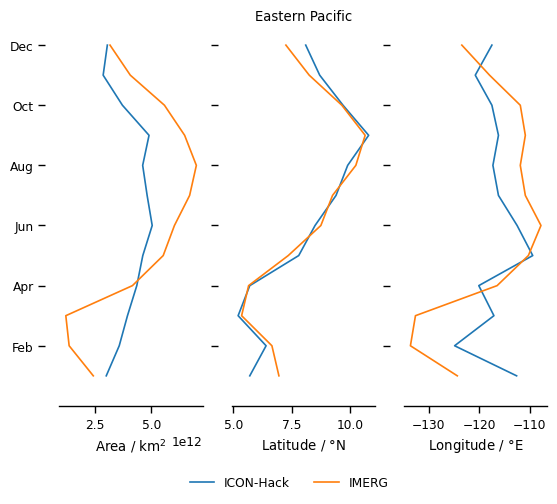

In [ ]:
sns.set_context("paper") 
fig = plt.figure(figsize=(16/2.54, 12/2.54))
ax1 = fig.add_subplot(131)
ax1.plot(scal_epac,pr_imerg.month)
ax1.plot(scal_epac_imerg,pr_imerg.month)
sns.despine(offset=10,ax=ax1)
ax1.set_xlabel(r'Area / km$^\mathrm{2}$')
ax1.spines['left'].set_visible(False)
ax1.set_yticks([2,4,6,8,10,12])
ax1.set_yticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])

ax2 = fig.add_subplot(132)
ax2.plot(epac_lati,pr_imerg.month)
ax2.plot(epac_lati_imerg,pr_imerg.month)
sns.despine(offset=10,ax=ax2)
ax2.set_xlabel(r'Latitude / $\degree$N')
ax2.spines['left'].set_visible(False)
ax2.set_yticklabels({})
ax2.set_title('Eastern Pacific')

ax3 = fig.add_subplot(133)
ax3.plot(epac_loni,pr_imerg.month,label='ICON-Hack')
ax3.plot(epac_loni_imerg,pr_imerg.month,label='IMERG')
ax3.set_xlabel(r'Longitude / $\degree$E')
sns.despine(offset=10,ax=ax3)
ax3.spines['left'].set_visible(False)
ax3.set_yticklabels({})
ax3.legend(loc='upper center', bbox_to_anchor=(-0.8, -0.2),
          ncol=2,frameon=False)

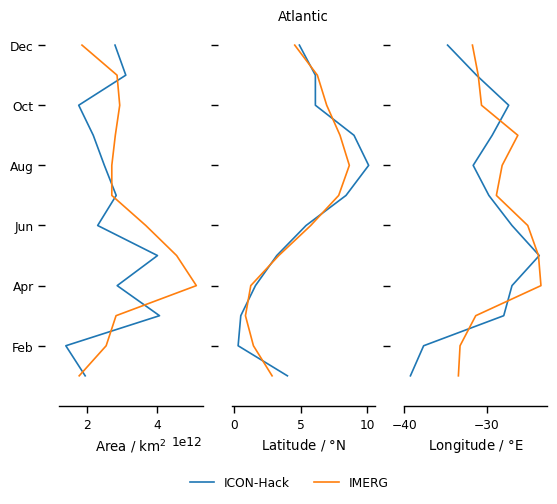

In [114]:
sns.set_context("paper") 
fig = plt.figure(figsize=(16/2.54, 12/2.54))
ax1 = fig.add_subplot(131)
ax1.plot(scal_atl,pr_imerg.month)
ax1.plot(scal_atl_imerg,pr_imerg.month)
sns.despine(offset=10,ax=ax1)
ax1.set_xlabel(r'Area / km$^\mathrm{2}$')
ax1.spines['left'].set_visible(False)
ax1.set_yticks([2,4,6,8,10,12])
ax1.set_yticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])

ax2 = fig.add_subplot(132)
ax2.plot(atl_lati,pr_imerg.month)
ax2.plot(atl_lati_imerg,pr_imerg.month)
sns.despine(offset=10,ax=ax2)
ax2.set_xlabel(r'Latitude / $\degree$N')
ax2.spines['left'].set_visible(False)
ax2.set_yticklabels({})
ax2.set_title('Atlantic')

ax3 = fig.add_subplot(133)
ax3.plot(atl_loni,pr_imerg.month,label='ICON-Hack')
ax3.plot(atl_loni_imerg,pr_imerg.month,label='IMERG')
ax3.set_xlabel(r'Longitude / $\degree$E')
sns.despine(offset=10,ax=ax3)
ax3.spines['left'].set_visible(False)
ax3.set_yticklabels({})
ax3.legend(loc='upper center', bbox_to_anchor=(-0.8, -0.2),
          ncol=2,frameon=False)

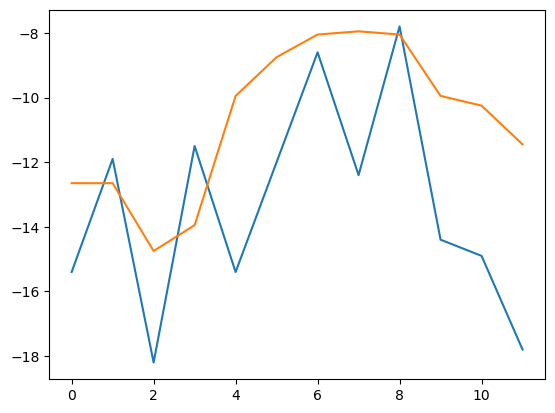

In [65]:
plt.plot(spac_lati)
plt.plot(spac_lati_imerg)

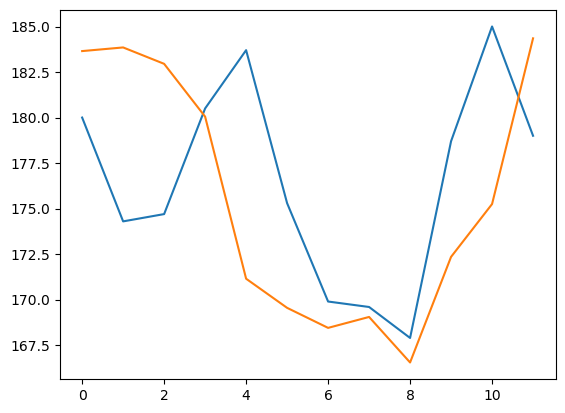

In [66]:
plt.plot(spac_loni)
plt.plot(spac_loni_imerg)

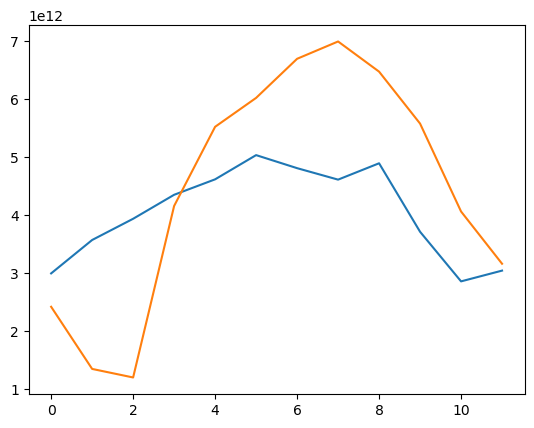

In [67]:
plt.plot(scal_epac)
plt.plot(scal_epac_imerg)

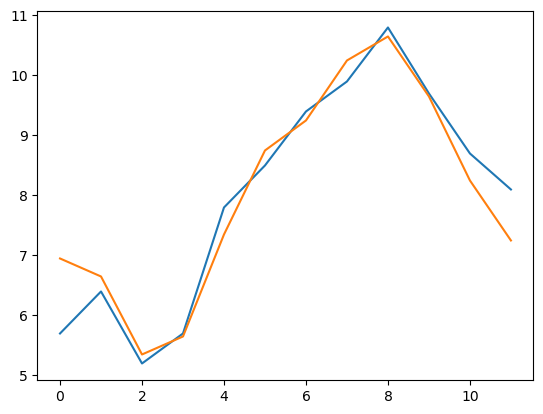

In [68]:
plt.plot(epac_lati)
plt.plot(epac_lati_imerg)

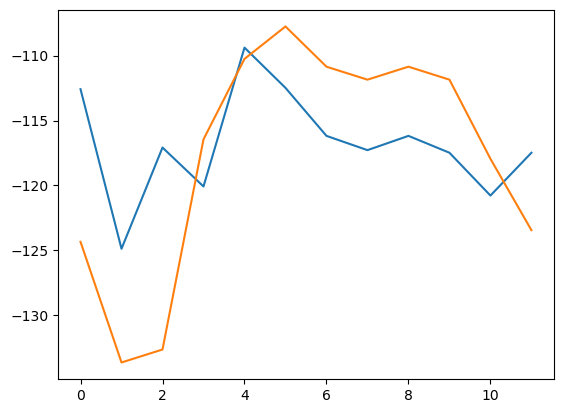

In [69]:
plt.plot(epac_loni)
plt.plot(epac_loni_imerg)